# ANALISIS SENSITIVITAS — Bagian A dan Bagian B

**Bagian A** mengikuti Mai & Smith (2018): setiap parameter diubah ±10%, lalu dampaknya terhadap
keluaran tahun 2050 diperingkat. Pemeringkatan dilakukan terhadap **enam variabel** (Jumlah Wisatawan
sebagai acuan utama, ditambah Lahan Terbangun, PDRB, Jumlah Hotel, Tenaga Kerja, dan Jumlah ODTW),
agar parameter yang hanya berpengaruh pada satu subsistem tetap terlihat.

**Bagian B** menguji parameter berstatus asumsi dan tuas kebijakan pada rentang penuhnya.

**Ketentuan parameter berpasangan.** Parameter yang saling terikat dihitung ulang pada setiap titik uji:
LPE↔LPD (rasio 0,75); TPK Ambang↔Sensitivitas Konstruksi; Laju Demolisi↔Sensitivitas Konstruksi;
Laju Penutupan ODTW↔Sensitivitas ODTW dan Non Investasi; Luas Lahan↔Kepadatan Referensi dan RDDL Referensi.
Ditambahkan pada versi ini: **ketiga bobot Daya Tarik dinormalisasi ulang agar berjumlah 1**, dan
**LPE/LPD diturunkan ulang** setiap kali parameter pembentuk indeks Daya Tarik 2024 berubah
(bobot, elastisitas, batas efek, nilai referensi, luas lahan), karena LPE diturunkan dari indeks tersebut.
Saklar `KONSISTEN` mengatur kedua penambahan itu; `False` mengembalikan perilaku versi sebelumnya.

**Catatan teknis.** Nilai awal stok ditetapkan lewat `initial_condition`, bukan `params`, karena
menetapkan stok lewat `params` mengubahnya menjadi konstanta sepanjang simulasi.


In [2]:
!pip install pysd openpyxl matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 15.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 7.5 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, pysd
warnings.filterwarnings("ignore")

FOLDER = Path("/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[03] Analisis Sensitivitas/Final")
FILE = FOLDER / "MODEL SISTEM DINAMIS.mdl"
FOLDER.mkdir(parents=True, exist_ok=True)

if not FILE.exists():
    from google.colab import files
    print(f"'{FILE.name}' belum ada, silakan upload:")
    files.upload()

## Data dan fungsi perhitungan ulang parameter berpasangan

In [6]:
HOTEL   = np.array([1165,1170,1179,1617,1817,1848,1696,1818,1820,2000,2291], float)   # 2015-2025
TPK_BPS = np.array([34.89,37.72,45.08,45.11,45.34,28.90,27.48,44.99,44.77,42.17,38.07])/100
INV     = np.array([53.0896,373.8424,165.3915,568.3341,741.4483,489.6932,848.8042,463.5886,
                    1175.2552,712.2835,1325.950399])
ODTW    = np.array([165,158,171,177,189,180,170,183,201,218,201], float)
JW2025, LAHAN2025, PORSI_SWASTA = 40695654.0, 55029.5352961885, 0.5709

def sens_konstruksi(ambang, demolisi):
    return ((HOTEL[-1]-HOTEL[0]) + demolisi*HOTEL[:-1].sum()) / \
           np.sum(INV[1:]*np.maximum(0.0, TPK_BPS[1:]-ambang))

def param_odtw(penutupan):
    sigma = (ODTW[-1]-ODTW[0]) + penutupan*ODTW[:-1].sum()
    return PORSI_SWASTA*sigma/INV[1:].sum(), (1-PORSI_SWASTA)*sigma/10

assert abs(sens_konstruksi(0.275, 0.05) - 2.313846) < 1e-4
s0, n0 = param_odtw(0.0499327)
assert abs(s0-0.010517) < 1e-5 and abs(n0-5.4273) < 1e-3
print("Cek identitas parameter berpasangan lolos.")

Cek identitas parameter berpasangan lolos.


## Penurunan ulang LPE dan LPD (penambahan)

In [7]:
# ============ PENAMBAHAN: LPE/LPD diturunkan ulang agar konsisten dengan data 2024-2025 ============
# LPE diturunkan dari pertumbuhan wisatawan 2024->2025 dan indeks Daya Tarik 2024:
#     LPE = g / (Daya Tarik 2024 - rasio LPD/LPE),   LPD = rasio x LPE
# Indeks 2024 dibentuk oleh bobot, elastisitas, batas efek, nilai referensi, dan luas lahan, sehingga
# perubahan salah satunya menuntut LPE/LPD dihitung ulang (pasangan yang sebelumnya belum tercakup).
KONSISTEN = True       # False = perilaku lama (LPE/LPD tetap), dipakai sebagai pembanding

JW2024, ODTW2024, LAHAN2024 = 38134536.0, 218.0, 73511.574651116     # Master Data 2024
ODTW2025 = 201.0

DTD_DASAR = {
    "Bobot ODTW":0.40, "Bobot Kepadatan":0.35, "Bobot Daya Dukung Lahan":0.25,
    "Elastisitas Daya Tarik ODTW":0.30, "Batas Maksimum Efek ODTW":1.5,
    "ODTW Referensi":201.0, "Luas Lahan Tersedia":317036.0,
    "Kepadatan Referensi":JW2025/317036.0, "Rasio Daya Dukung Lahan Referensi":1 - LAHAN2025/317036.0,
}

def dtd(tahun, ubah=None):
    """Indeks Daya Tarik pada tahun 2024 atau 2025, memakai persamaan model."""
    P = {**DTD_DASAR, **(ubah or {})}
    od, jw, lh = {2024:(ODTW2024, JW2024, LAHAN2024), 2025:(ODTW2025, JW2025, LAHAN2025)}[tahun]
    luas = P["Luas Lahan Tersedia"]
    rddl = max(0.0, 1 - lh/luas)
    return (P["Bobot ODTW"]*min(P["Batas Maksimum Efek ODTW"], (od/P["ODTW Referensi"])**P["Elastisitas Daya Tarik ODTW"])
          + P["Bobot Kepadatan"]*min(1.0, P["Kepadatan Referensi"]/(jw/luas))
          + P["Bobot Daya Dukung Lahan"]*(rddl/P["Rasio Daya Dukung Lahan Referensi"]))

def lpe_konsisten(ubah=None, rasio=0.75):
    return (JW2025/JW2024 - 1) / (dtd(2024, ubah) - rasio)

def tambah_lpe(p, rasio=0.75):
    """Bila p mengubah parameter pembentuk indeks Daya Tarik, LPE dan LPD diturunkan ulang."""
    if not KONSISTEN:
        return p
    if "Laju Pertumbuhan Eksternal" in p or "Laju Penurunan Dasar" in p:
        return p                       # LPE/LPD sengaja diubah langsung (uji LPE dan uji rasio)
    if any(k in DTD_DASAR for k in p):
        L = lpe_konsisten(p, rasio)
        return {**p, "Laju Pertumbuhan Eksternal":L, "Laju Penurunan Dasar":rasio*L}
    return p

assert abs(lpe_konsisten() - 0.27726) < 5e-6, "LPE turunan tidak cocok dengan 0,27726"
print(f"Daya Tarik 2024 = {dtd(2024):.5f} (harus 0,99223) | LPE turunan = {lpe_konsisten():.5f} (harus 0,27726)")
print("Cek penurunan LPE lolos. KONSISTEN =", KONSISTEN)

Daya Tarik 2024 = 0.99223 (harus 0,99223) | LPE turunan = 0.27726 (harus 0,27726)
Cek penurunan LPE lolos. KONSISTEN = True


In [8]:
model = pysd.read_vensim(str(FILE))
TPK       = [k for k in model.namespace if "TPK" in k and "Ambang" not in k][0]
ODTW_FLOW = [k for k in model.namespace if "Pembangunan" in k and "ODTW" in k][0]
LAMA      = [k for k in model.namespace if "Lama Menginap" in k][0]
KAMAR     = [k for k in model.namespace if "Kamar per Unit" in k][0]

STOK = ["Jumlah Wisatawan","Jumlah Hotel dan Akomodasi","Jumlah Objek Daya Tarik Wisata",
        "Tenaga Kerja Pariwisata","Lahan Terbangun"]
FLOW = ["Laju Kedatangan Wisatawan","Laju Penurunan Wisatawan","Laju Konstruksi Hotel dan Akomodasi",
        "Laju Demolisi Hotel dan Akomodasi",ODTW_FLOW,"Laju Penutupan ODTW",
        "Laju Penyerapan Tenaga Kerja Pariwisata","Laju Keluar Tenaga Kerja Pariwisata",
        "Laju Konversi Lahan Pariwisata","Laju Konversi Lahan Non Pariwisata"]
AUX  = ["Daya Tarik Destinasi Wisata","Kepadatan Wisatawan","Rasio Daya Dukung Lahan",
        "Pengeluaran Wisatawan","PDRB Sektor Pariwisata","Investasi Sektor Pariwisata",
        "Total Malam Menginap","Rasio Permintaan terhadap Kapasitas Kamar",TPK,
        "Intensitas Tenaga Kerja","Tenaga Kerja Dibutuhkan"]
VAR = STOK + FLOW + AUX
BERSIH = [v.strip('"') for v in VAR]

def jalankan(params=None, awal=None, final=2050):
    """awal = nilai awal stok (initial_condition). Jangan menetapkan stok lewat params."""
    m = pysd.read_vensim(str(FILE))
    kw = dict(params=params or {}, return_columns=VAR, final_time=final,
              return_timestamps=list(range(2025, final+1)))
    if awal: kw["initial_condition"] = (2025, awal)
    r = m.run(**kw).apply(lambda s: np.real(s.astype(complex)))
    r.columns = [c.strip('"') for c in r.columns]
    return r

def ringkas(r):
    d = {f"{v} 2050": r[v][2050] for v in BERSIH}
    for f in [x.strip('"') for x in FLOW]:
        d[f"{f} (kumulatif 2025-2050)"] = r[f].sum()
    return d

BASE = jalankan(); base = ringkas(BASE)
print(f"BASE 2050 — Wisatawan {BASE['Jumlah Wisatawan'][2050]:,.0f} | "
      f"Lahan {BASE['Lahan Terbangun'][2050]:,.0f} ha | PDRB {BASE['PDRB Sektor Pariwisata'][2050]:,.1f}")

BASE 2050 — Wisatawan 96,197,154 | Lahan 122,208 ha | PDRB 40,061.1


## BAGIAN A — ±10% seluruh parameter

Dikeluarkan dari Bagian A: **Insentif Kebijakan** dan **Kebijakan Konservasi Lahan** (bernilai 0 pada
BAU sehingga ±10% tidak bermakna; keduanya diuji rentang penuh di Bagian B), serta **Tahun Dasar
Intensitas Tenaga Kerja** (satuan tahun).

In [9]:
DASAR = {
 "Laju Pertumbuhan Eksternal":0.27726, "Laju Penurunan Dasar":0.207945,
 "Pengeluaran per Kunjungan":0.00272021, "Rasio Nilai Tambah Pariwisata":0.153094,
 "Rasio Investasi terhadap PDRB":0.0488174, "Sensitivitas Konstruksi terhadap TPK":2.31385,
 "TPK Ambang":0.275, "Laju Demolisi Dasar":0.05, "Sensitivitas ODTW terhadap Investasi":0.01052,
 "Laju Pembangunan ODTW Non Investasi":5.427, "Laju Penutupan Dasar ODTW":0.0499327,
 "Laju Konversi Dasar":0.0436052, "Lahan Per Hotel dan Akomodasi":0.1, "Lahan Per ODTW":0.5,
 "Luas Lahan Tersedia":317036.0, "Proporsi Wisatawan Menginap":0.2058,
 LAMA:1.427, "Tingkat Penghunian Ganda Kamar":2.07, KAMAR:21.4168, "Malam Tersedia per Kamar":329.03,
 "Bobot ODTW":0.4, "Bobot Kepadatan":0.35, "Bobot Daya Dukung Lahan":0.25,
 "Elastisitas Daya Tarik ODTW":0.3, "Batas Maksimum Efek ODTW":1.5, "ODTW Referensi":201.0,
 "Kepadatan Referensi":128.363, "Rasio Daya Dukung Lahan Referensi":0.826425,
 "Intensitas Tenaga Kerja Awal":21.5366, "Laju Kenaikan Produktivitas":0.0110205,
 "Laju Keluar Dasar Tenaga Kerja":0.03, "Waktu Penyesuaian Tenaga Kerja":1.0,
}

BOBOT = ["Bobot ODTW","Bobot Kepadatan","Bobot Daya Dukung Lahan"]

def pasangan(nama, nilai):
    p = {nama: nilai}
    if nama == "Laju Pertumbuhan Eksternal":
        p["Laju Penurunan Dasar"] = 0.75*nilai
    elif nama == "TPK Ambang":
        p["Sensitivitas Konstruksi terhadap TPK"] = sens_konstruksi(nilai, 0.05)
    elif nama == "Laju Demolisi Dasar":
        p["Sensitivitas Konstruksi terhadap TPK"] = sens_konstruksi(0.275, nilai)
    elif nama == "Laju Penutupan Dasar ODTW":
        s, ni = param_odtw(nilai)
        p["Sensitivitas ODTW terhadap Investasi"] = s
        p["Laju Pembangunan ODTW Non Investasi"] = ni
    elif nama == "Luas Lahan Tersedia":
        p["Kepadatan Referensi"] = JW2025/nilai
        p["Rasio Daya Dukung Lahan Referensi"] = 1 - LAHAN2025/nilai
    elif nama in BOBOT and KONSISTEN:                      # BARU: ketiga bobot tetap berjumlah 1
        lain = [b for b in BOBOT if b != nama]
        sisa, tot = 1 - nilai, sum(DASAR[b] for b in lain)
        for b in lain:
            p[b] = DASAR[b]*sisa/tot
    return tambah_lpe(p)                                   # BARU: LPE/LPD diturunkan ulang bila indeks 2024 berubah

baris = []
for nama, nilai in DASAR.items():
    for arah, f in [("-10%", 0.9), ("+10%", 1.1)]:
        p = pasangan(nama, nilai*f)
        ring = ringkas(jalankan(p))
        baris.append({"Parameter":nama.strip('"'), "Nilai dasar":nilai, "Arah":arah, "Nilai uji":nilai*f,
                      "Parameter berpasangan":"; ".join(f"{k}={v:.6g}" for k,v in p.items() if k!=nama) or "-",
                      **{f"{k} (% thd BASE)": (100*(v-base[k])/base[k] if base[k]!=0 else np.nan)
                         for k,v in ring.items()}, **ring})
hasilA = pd.DataFrame(baris)
print(f"{len(hasilA)} run selesai.")

64 run selesai.


In [10]:
FOKUS = {"Jumlah Wisatawan 2050":"Wisatawan",
         "Lahan Terbangun 2050":"Lahan",
         "PDRB Sektor Pariwisata 2050":"PDRB",
         "Jumlah Hotel dan Akomodasi 2050":"Hotel",
         "Tenaga Kerja Pariwisata 2050":"Tenaga Kerja",
         "Jumlah Objek Daya Tarik Wisata 2050":"ODTW"}

UTAMA = list(FOKUS.values())[0]          # dasar pengurutan tabel

tor = []
for nama in DASAR:
    nm = nama.strip('"')
    sub = hasilA[hasilA.Parameter == nm]
    d = {"Parameter": nm}
    for kol, lab in FOKUS.items():
        neg = sub[sub.Arah == "-10%"][f"{kol} (% thd BASE)"].iloc[0]
        pos = sub[sub.Arah == "+10%"][f"{kol} (% thd BASE)"].iloc[0]
        d[f"{lab} -10%"], d[f"{lab} +10%"], d[f"{lab} |maks|"] = neg, pos, max(abs(neg), abs(pos))
    tor.append(d)

tornado = pd.DataFrame(tor)
for lab in FOKUS.values():
    tornado[f"Peringkat {lab}"] = tornado[f"{lab} |maks|"].rank(ascending=False).astype(int)
tornado = tornado.sort_values(f"{UTAMA} |maks|", ascending=False)

display(tornado[["Parameter"] + [f"{lab} |maks|" for lab in FOKUS.values()]
                              + [f"Peringkat {lab}" for lab in FOKUS.values()]].round(3))

print("Parameter teratas per variabel fokus:")
for lab in FOKUS.values():
    t = tornado[tornado[f"{lab} |maks|"] > 0].nlargest(5, f"{lab} |maks|")
    print(f"  {lab}: " + "; ".join(f"{r.Parameter} {r[f'{lab} |maks|']:.2f}%" for _, r in t.iterrows()))

,Parameter,Wisatawan |maks|,Lahan |maks|,PDRB |maks|,Hotel |maks|,Tenaga Kerja |maks|,ODTW |maks|,Peringkat Wisatawan,Peringkat Lahan,Peringkat PDRB,Peringkat Hotel,Peringkat Tenaga Kerja,Peringkat ODTW
1,Laju Penurunan Dasar,42.074,0.263,42.074,36.996,40.065,16.650,1,3,1,1,1,1
26,Kepadatan Referensi,8.606,0.062,8.606,7.999,8.385,3.955,2,11,4,7,5,6
21,Bobot Kepadatan,7.488,0.040,7.488,6.322,7.039,2.560,3,16,5,8,6,8
20,Bobot ODTW,7.269,0.035,7.269,5.914,6.732,2.243,4,18,6,9,7,10
27,Rasio Daya Dukung Lahan Referensi,5.090,0.133,5.090,4.441,4.850,1.891,5,4,7,11,9,11
0,Laju Pertumbuhan Eksternal,5.058,0.041,5.058,4.855,4.989,2.591,6,15,8,10,8,7
25,ODTW Referensi,3.537,0.018,3.537,2.955,3.313,1.173,7,23,9,15,10,12
8,Sensitivitas ODTW terhadap Investasi,2.568,0.029,2.568,2.117,2.393,7.247,8,19,10,17,12,2
4,Rasio Investasi terhadap PDRB,2.562,0.048,2.562,4.105,2.387,7.245,10,13,11,13,13,4
3,Rasio Nilai Tambah Pariwisata,2.562,0.048,12.818,4.105,12.626,7.245,10,13,3,13,2,4


Parameter teratas per variabel fokus:
  Wisatawan: Laju Penurunan Dasar 42.07%; Kepadatan Referensi 8.61%; Bobot Kepadatan 7.49%; Bobot ODTW 7.27%; Rasio Daya Dukung Lahan Referensi 5.09%
  Lahan: Laju Konversi Dasar 6.64%; Luas Lahan Tersedia 2.67%; Laju Penurunan Dasar 0.26%; Rasio Daya Dukung Lahan Referensi 0.13%; Tingkat Penghunian Ganda Kamar 0.08%
  PDRB: Laju Penurunan Dasar 42.07%; Pengeluaran per Kunjungan 12.82%; Rasio Nilai Tambah Pariwisata 12.82%; Kepadatan Referensi 8.61%; Bobot Kepadatan 7.49%
  Hotel: Laju Penurunan Dasar 37.00%; Tingkat Penghunian Ganda Kamar 8.80%; Malam Tersedia per Kamar 8.80%; Rata-rata Kamar per Unit Akomodasi 8.80%; Rata-rata Lama Menginap Tamu 8.19%
  Tenaga Kerja: Laju Penurunan Dasar 40.07%; Rasio Nilai Tambah Pariwisata 12.63%; Pengeluaran per Kunjungan 12.63%; Intensitas Tenaga Kerja Awal 10.00%; Kepadatan Referensi 8.38%
  ODTW: Laju Penurunan Dasar 16.65%; Sensitivitas ODTW terhadap Investasi 7.25%; Rasio Investasi terhadap PDRB 7.25%; Ra

### Grafik tornado

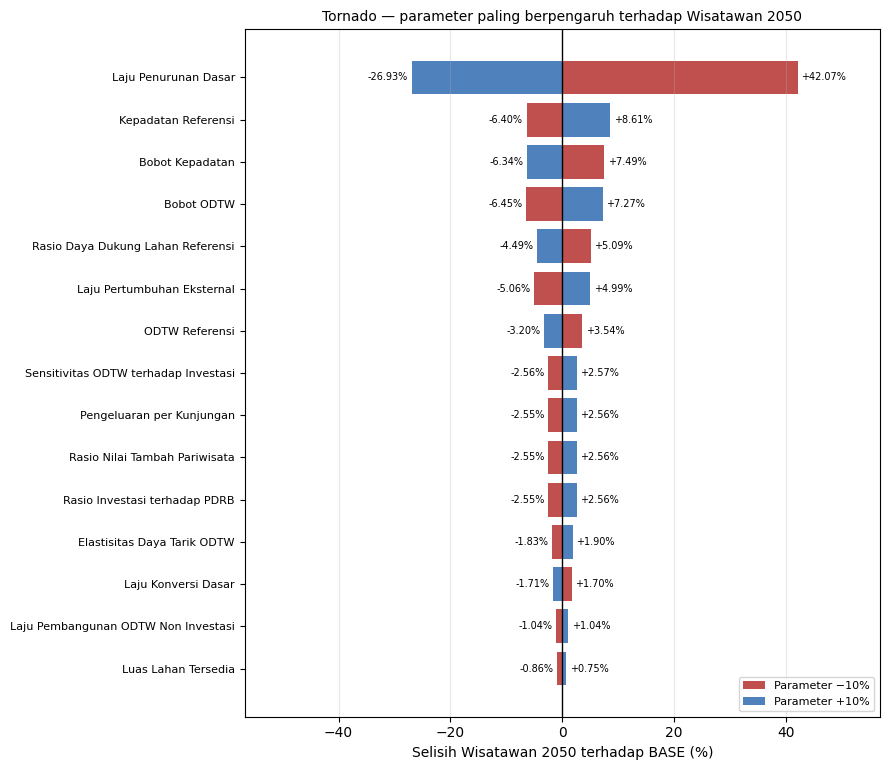

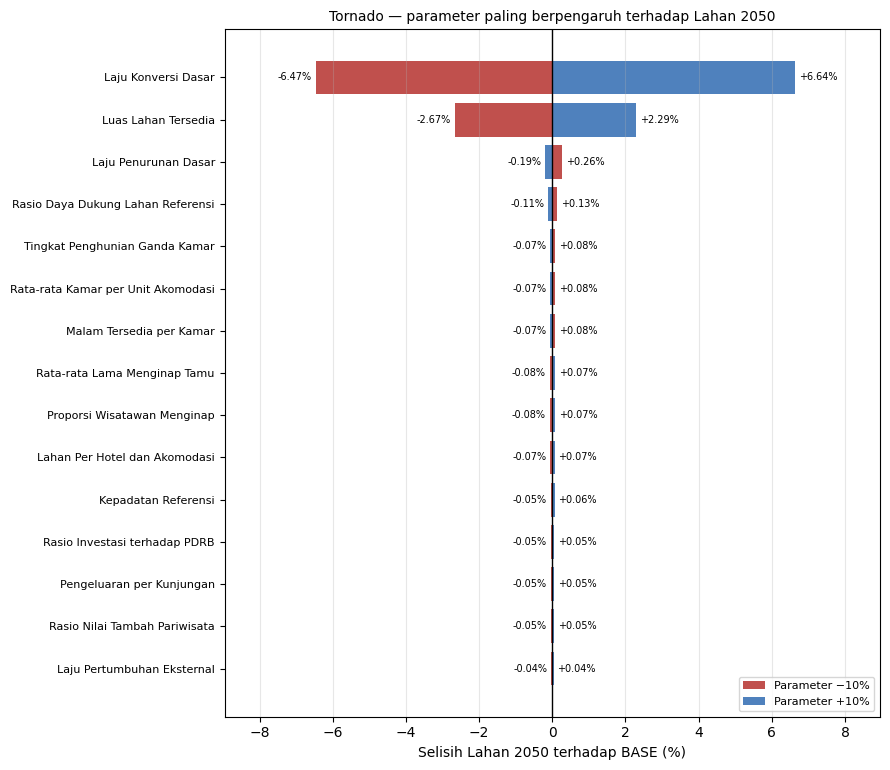

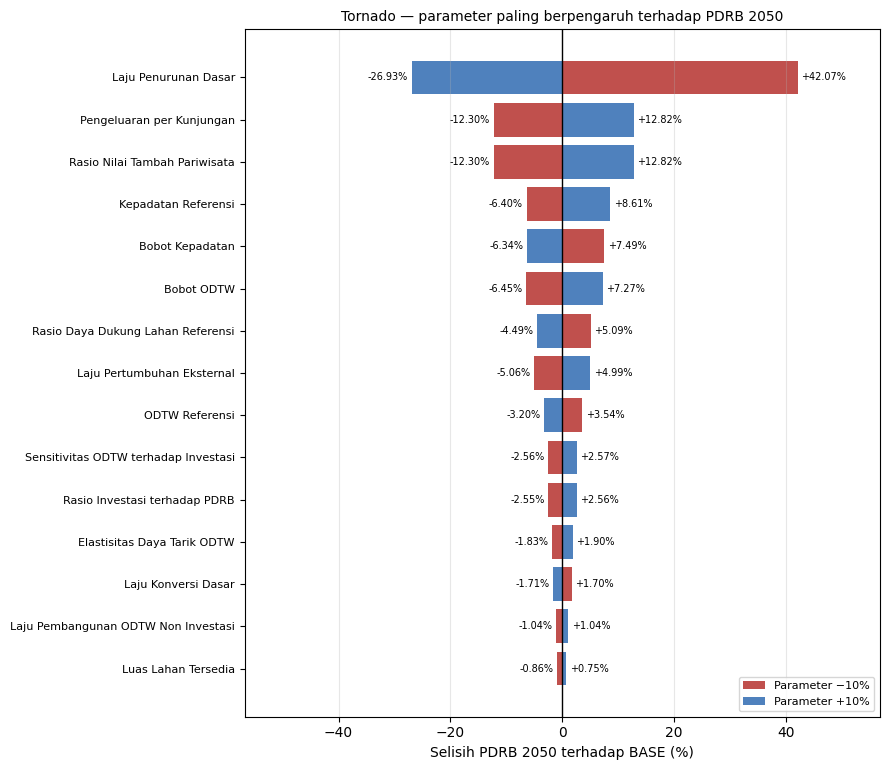

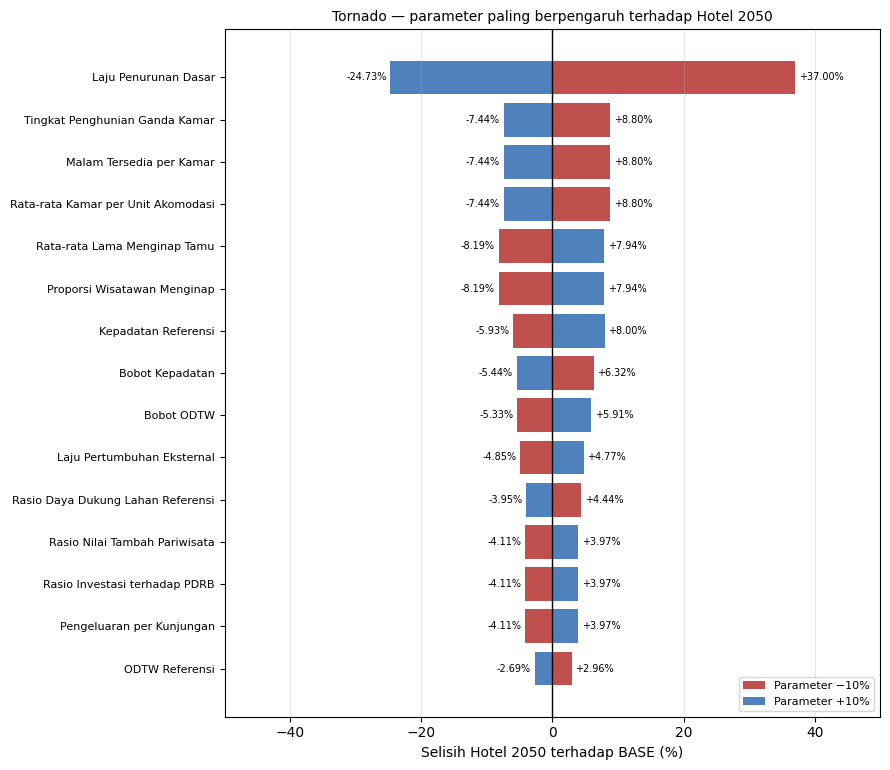

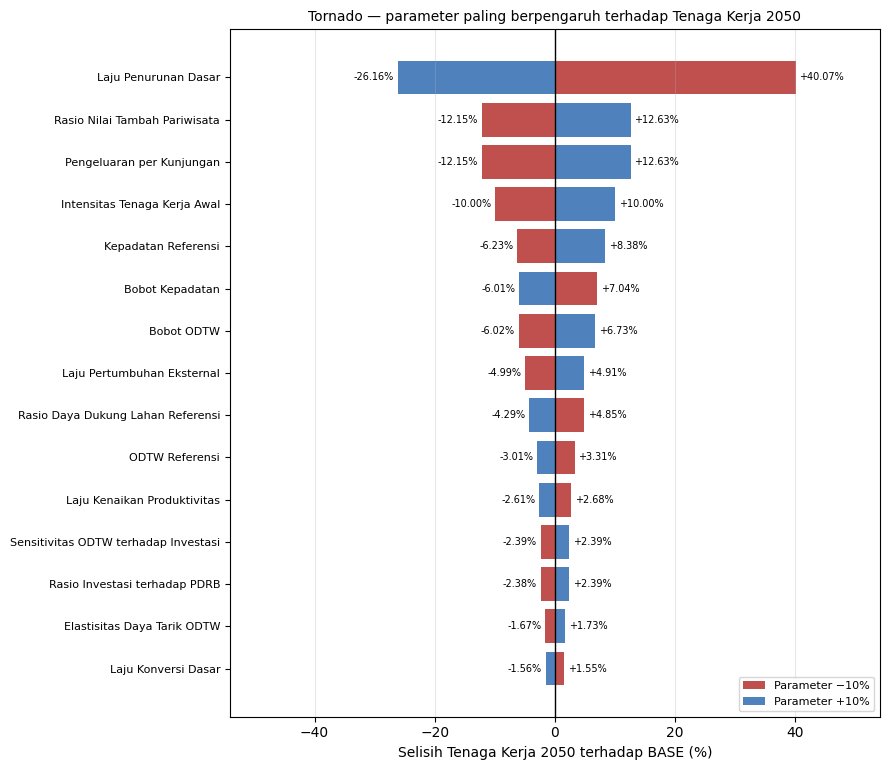

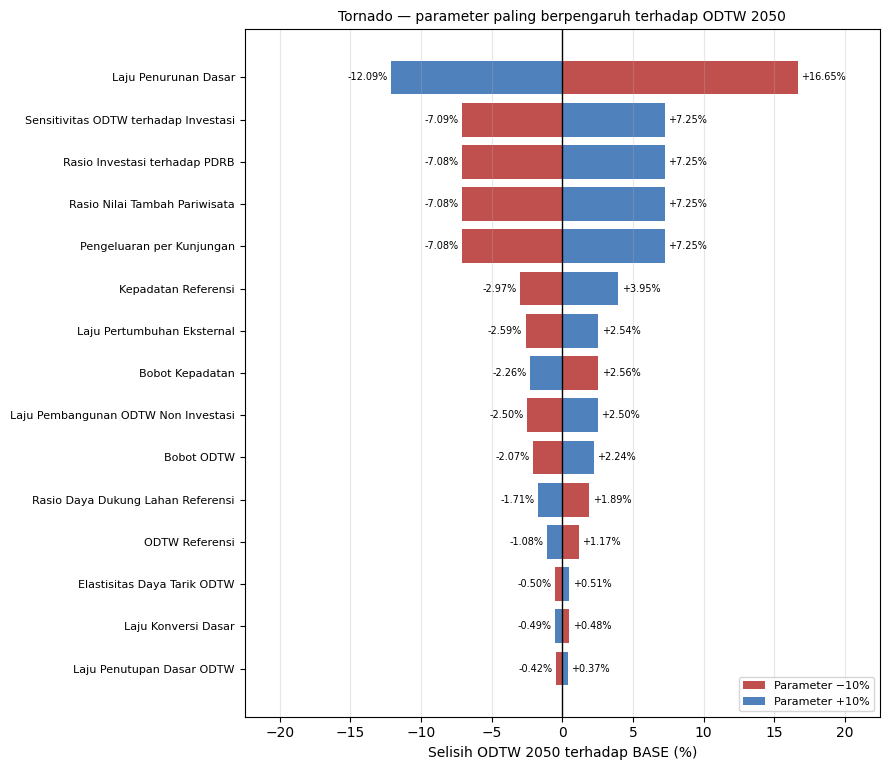

In [11]:
for kol, lab in FOKUS.items():
    t = tornado.sort_values(f"{lab} |maks|").tail(15)
    t = t[t[f"{lab} |maks|"] > 0]                     # buang parameter tanpa pengaruh
    if t.empty:
        print(f"Tidak ada parameter berpengaruh terhadap {lab}; grafik dilewati.")
        continue
    y = np.arange(len(t))
    neg, pos = t[f"{lab} -10%"].values, t[f"{lab} +10%"].values

    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.42*len(t) + 1.5)))
    ax.barh(y, neg, color="#c0504d", label="Parameter \u221210%")
    ax.barh(y, pos, color="#4f81bd", label="Parameter +10%")

    lebar = max(abs(np.concatenate([neg, pos]))) or 1
    for i, (n, p) in enumerate(zip(neg, pos)):
        for v in (n, p):
            if abs(v) < 1e-9:
                continue
            ax.text(v + (0.015*lebar if v >= 0 else -0.015*lebar), i, f"{v:+.2f}%",
                    va="center", ha="left" if v >= 0 else "right", fontsize=7)

    ax.set_yticks(y); ax.set_yticklabels(t["Parameter"], fontsize=8)
    ax.axvline(0, color="black", lw=1)
    ax.set_xlim(-1.35*lebar, 1.35*lebar)
    ax.set_xlabel(f"Selisih {lab} 2050 terhadap BASE (%)")
    ax.set_title(f"Tornado \u2014 parameter paling berpengaruh terhadap {lab} 2050", fontsize=10)
    ax.grid(alpha=0.3, axis="x"); ax.legend(fontsize=8, loc="lower right")
    fig.tight_layout()
    fig.savefig(FOLDER / f"tornado_{lab.replace(' ', '_')}.png", dpi=150)
    plt.show()

## BAGIAN B — rentang penuh parameter asumsi dan tuas kebijakan

In [12]:
UJI = []
def tambah(kel, ket, p, awal=None): UJI.append((kel, ket, tambah_lpe(p), awal))     # BARU: tambah_lpe

for lab, (bo, bk, bl) in {"0,50/0,25/0,25":(0.50,0.25,0.25), "0,30/0,45/0,25":(0.30,0.45,0.25),
                          "1/3 masing-masing":(1/3,1/3,1/3)}.items():
    tambah("Bobot Daya Tarik", lab, {"Bobot ODTW":bo,"Bobot Kepadatan":bk,"Bobot Daya Dukung Lahan":bl})
for v in [0.2, 0.4]:      tambah("Elastisitas Daya Tarik ODTW", f"{v}", {"Elastisitas Daya Tarik ODTW":v})
for v in [1.25, 1.875]:   tambah("Batas Maksimum Efek ODTW", f"{v}", {"Batas Maksimum Efek ODTW":v})
for v in [0.05, 0.2]:     tambah("Lahan Per Hotel dan Akomodasi", f"{v}", {"Lahan Per Hotel dan Akomodasi":v})
for v in [0.1, 2.0]:      tambah("Lahan Per ODTW", f"{v}", {"Lahan Per ODTW":v})
for v in [0.20, 0.35]:    tambah("TPK Ambang", f"{v}", {"TPK Ambang":v,
                                  "Sensitivitas Konstruksi terhadap TPK":sens_konstruksi(v,0.05)})
for v in [0.02, 0.08]:    tambah("Laju Demolisi Dasar", f"{v}", {"Laju Demolisi Dasar":v,
                                  "Sensitivitas Konstruksi terhadap TPK":sens_konstruksi(0.275,v)})
for v in [2.0, 3.0]:      tambah("Waktu Penyesuaian Tenaga Kerja", f"{v}", {"Waktu Penyesuaian Tenaga Kerja":v})
for v in [0.05, 0.10]:    tambah("Laju Keluar Dasar Tenaga Kerja", f"{v}", {"Laju Keluar Dasar Tenaga Kerja":v})
for v in [0.0, 0.0154]:   tambah("Laju Kenaikan Produktivitas", f"{v}", {"Laju Kenaikan Produktivitas":v})
for v in [0.60, 0.90]:    tambah("Rasio LPD/LPE", f"{v}", {"Laju Penurunan Dasar":v*0.27726})
for v in [0.01, 0.07]:
    s, ni = param_odtw(v)
    tambah("Laju Penutupan Dasar ODTW", f"{v}", {"Laju Penutupan Dasar ODTW":v,
            "Sensitivitas ODTW terhadap Investasi":s, "Laju Pembangunan ODTW Non Investasi":ni})
for v in [189.0, 218.0]:  # nilai awal stok lewat initial_condition, referensi berpasangan
    tambah("ODTW 2025 (nilai awal & referensi)", f"{v}", {"ODTW Referensi":v},
           {"Jumlah Objek Daya Tarik Wisata":v})
for v in [0.0034118, 0.0851069]:
    tambah("Laju Konversi Dasar (CI 95%)", f"{v}", {"Laju Konversi Dasar":v})
# Insentif diuji hanya sampai 0,5 = batas atas rentang deklarasi model [0; 0,5]
for v in [0.1, 0.3, 0.5]:        tambah("Insentif Kebijakan", f"{v}", {"Insentif Kebijakan":v})
for v in [0.25, 0.5, 0.75, 1.0]: tambah("Kebijakan Konservasi Lahan", f"{v}", {"Kebijakan Konservasi Lahan":v})

# OPSIONAL: varian rasio yang konsisten dengan data (LPE diturunkan ulang, pertumbuhan 2024-2025 tetap terpenuhi)
for v in [0.60, 0.90]:
    L = lpe_konsisten(rasio=v)
    UJI.append(("Rasio LPD/LPE (konsisten data)", f"{v}",
                {"Laju Pertumbuhan Eksternal":L, "Laju Penurunan Dasar":v*L}, None))

barisB = []
for kel, ket, p, awal in UJI:
    r = jalankan(p, awal=awal)
    d = {"Kelompok":kel, "Nilai uji":ket,
         "Parameter diubah":"; ".join(f"{k}={v:.6g}" for k,v in p.items())
                            + ("" if not awal else "; nilai awal " + "; ".join(f"{k}={v:.6g}" for k,v in awal.items()))}
    for v in BERSIH:
        d[f"{v} 2050"] = r[v][2050]
        d[f"{v} (%)"] = 100*(r[v][2050]-base[f"{v} 2050"])/base[f"{v} 2050"] if base[f"{v} 2050"] != 0 else np.nan
    barisB.append(d)
hasilB = pd.DataFrame(barisB)

VAR_RINGKAS = ["Jumlah Wisatawan","Lahan Terbangun","PDRB Sektor Pariwisata",
               "Jumlah Hotel dan Akomodasi","Tenaga Kerja Pariwisata","Jumlah Objek Daya Tarik Wisata"]

agg = {}
for v in VAR_RINGKAS:
    agg[f"{v} min (%)"]  = (f"{v} (%)", "min")
    agg[f"{v} maks (%)"] = (f"{v} (%)", "max")

rentang = hasilB.groupby("Kelompok").agg(**agg)
for v in VAR_RINGKAS:
    rentang[f"Lebar {v} (poin %)"] = rentang[f"{v} maks (%)"] - rentang[f"{v} min (%)"]
rentang = rentang.sort_values("Lebar Jumlah Wisatawan (poin %)", ascending=False)

print(f"{len(hasilB)} run Bagian B selesai.")
display(hasilB[["Kelompok", "Nilai uji"] + [f"{v} (%)" for v in VAR_RINGKAS]].round(2))
display(rentang[[f"Lebar {v} (poin %)" for v in VAR_RINGKAS]].round(2))

38 run Bagian B selesai.


,Kelompok,Nilai uji,Jumlah Wisatawan (%),Lahan Terbangun (%),PDRB Sektor Pariwisata (%),Jumlah Hotel dan Akomodasi (%),Tenaga Kerja Pariwisata (%),Jumlah Objek Daya Tarik Wisata (%)
0,Bobot Daya Tarik,"0,50/0,25/0,25",29.81,0.14,29.81,24.25,27.53,9.23
1,Bobot Daya Tarik,"0,30/0,45/0,25",-18.30,-0.10,-18.30,-15.71,-17.37,-6.52
2,Bobot Daya Tarik,1/3 masing-masing,-3.54,-0.01,-3.54,-2.37,-3.07,-0.52
3,Elastisitas Daya Tarik ODTW,0.2,-5.85,-0.02,-5.85,-4.59,-5.36,-1.61
4,Elastisitas Daya Tarik ODTW,0.4,6.65,0.03,6.65,5.11,6.02,1.75
5,Batas Maksimum Efek ODTW,1.25,0.00,0.00,0.00,0.00,0.00,0.00
6,Batas Maksimum Efek ODTW,1.875,0.00,0.00,0.00,0.00,0.00,0.00
7,Lahan Per Hotel dan Akomodasi,0.05,0.09,-0.34,0.09,0.07,0.08,0.03
8,Lahan Per Hotel dan Akomodasi,0.2,-0.18,0.68,-0.18,-0.15,-0.17,-0.05
9,Lahan Per ODTW,0.1,0.05,-0.18,0.05,0.04,0.04,0.01


,Lebar Jumlah Wisatawan (poin %),Lebar Lahan Terbangun (poin %),Lebar PDRB Sektor Pariwisata (poin %),Lebar Jumlah Hotel dan Akomodasi (poin %),Lebar Tenaga Kerja Pariwisata (poin %),Lebar Jumlah Objek Daya Tarik Wisata (poin %)
Kelompok,,,,,,
Rasio LPD/LPE,153.57,0.96,153.57,134.90,145.96,60.95
Rasio LPD/LPE (konsisten data),69.65,0.40,69.65,60.79,66.40,26.17
Bobot Daya Tarik,48.10,0.24,48.10,39.96,44.89,15.75
Laju Konversi Dasar (CI 95%),30.64,115.70,30.64,24.15,28.06,8.85
Elastisitas Daya Tarik ODTW,12.49,0.05,12.49,9.69,11.38,3.36
Insentif Kebijakan,10.35,0.18,10.35,15.06,9.60,30.58
Laju Penutupan Dasar ODTW,2.30,0.20,2.30,1.93,2.17,5.83
ODTW 2025 (nilai awal & referensi),1.51,0.00,1.51,0.81,1.24,2.36
Lahan Per Hotel dan Akomodasi,0.28,1.03,0.28,0.22,0.25,0.08


## Simpan Excel

In [13]:
SUF = "_konsisten" if KONSISTEN else "_lama"   # berkas lama tidak tertimpa
with pd.ExcelWriter(FOLDER / f"hasil_sensitivitas_bagianA{SUF}.xlsx") as w:
    tornado.round(6).to_excel(w, sheet_name="Peringkat Tornado", index=False)
    kol = ["Parameter","Arah","Nilai dasar","Nilai uji","Parameter berpasangan"]
    hasilA[kol + [c for c in hasilA.columns if "(% thd BASE)" in c]].round(6).to_excel(
        w, sheet_name="Selisih Persen", index=False)
    hasilA[["Parameter","Arah","Nilai uji"] + [c for c in hasilA.columns
            if "(% thd BASE)" not in c and c not in kol]].round(6).to_excel(
        w, sheet_name="Nilai 2050 dan Kumulatif", index=False)
    pd.DataFrame([base]).round(6).to_excel(w, sheet_name="BASE", index=False)
    BASE.round(4).to_excel(w, sheet_name="BASE seri")

with pd.ExcelWriter(FOLDER / f"hasil_sensitivitas_bagianB{SUF}.xlsx") as w:
    rentang.round(4).to_excel(w, sheet_name="Lebar Rentang")
    hasilB.round(4).to_excel(w, sheet_name="Hasil Rentang Penuh", index=False)
print("Kedua berkas tersimpan di", FOLDER)

Kedua berkas tersimpan di /content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[03] Analisis Sensitivitas/Final


## Perbandingan terhadap hasil versi sebelumnya (opsional)

In [15]:
try:
    lama = pd.read_excel(FOLDER/"hasil_sensitivitas_bagianA.xlsx", sheet_name="Peringkat Tornado")
    bnd = tornado[["Parameter","Wisatawan |maks|","Peringkat Wisatawan"]].merge(
          lama[["Parameter","Wisatawan |maks|","Peringkat Wisatawan"]], on="Parameter", suffixes=(" baru"," lama"))
    display(bnd.sort_values("Peringkat Wisatawan baru").head(15).round(2))
except FileNotFoundError:
    print("Berkas Bagian A lama tidak ditemukan di FOLDER; lewati perbandingan.")

,Parameter,Wisatawan |maks| baru,Peringkat Wisatawan baru,Wisatawan |maks| lama,Peringkat Wisatawan lama
0,Laju Penurunan Dasar,42.07,1,42.07,1
1,Kepadatan Referensi,8.61,2,8.90,6
2,Bobot Kepadatan,7.49,3,9.07,5
3,Bobot ODTW,7.27,4,22.79,2
4,Rasio Daya Dukung Lahan Referensi,5.09,5,11.48,3
5,Laju Pertumbuhan Eksternal,5.06,6,5.06,8
6,ODTW Referensi,3.54,7,6.62,7
7,Sensitivitas ODTW terhadap Investasi,2.57,8,2.57,9
8,Rasio Investasi terhadap PDRB,2.56,10,2.56,11
9,Rasio Nilai Tambah Pariwisata,2.56,10,2.56,11


## Angka untuk pencocokan

**Pemeriksaan awal:** Daya Tarik 2024 = 0,99223 dan LPE turunan = 0,27726. BASE 2050: Wisatawan 96.197.154;
Lahan 122.208 ha; PDRB 40.061,1.

**Bagian A (`KONSISTEN = True`), pengaruh maksimum terhadap Jumlah Wisatawan 2050:**

| Parameter | Baru | Peringkat baru | Versi lama | Peringkat lama |
|---|---|---|---|---|
| Laju Penurunan Dasar | 42,07 | 1 | 42,07 | 1 |
| Kepadatan Referensi | 8,61 | 2 | 8,90 | 6 |
| Bobot Kepadatan | 7,49 | 3 | 9,07 | 5 |
| Bobot ODTW | 7,27 | 4 | 22,79 | 2 |
| Rasio Daya Dukung Lahan Referensi | 5,09 | 5 | 11,48 | 3 |
| Laju Pertumbuhan Eksternal | 5,06 | 6 | 5,06 | 8 |
| ODTW Referensi | 3,54 | 7 | 6,62 | 7 |
| Bobot Daya Dukung Lahan | 0,51 | 16 | 10,28 | 4 |

**Bagian B, lebar rentang Jumlah Wisatawan (poin persen):** Bobot Daya Tarik 48,10 (lama 49,49);
Elastisitas 12,49 (lama 13,91); ODTW 2025 1,51 (lama 5,10); Rasio LPD/LPE 153,57 (tidak berubah);
Rasio LPD/LPE konsisten data 69,65 (varian baru).

**Jumlah run:** Bagian A 64; Bagian B 39 (37 ditambah 2 varian rasio konsisten data).

**Pemeriksaan bahwa patch tidak mengubah perilaku lama:** dengan `KONSISTEN = False`, Bobot ODTW +10%
harus menghasilkan +22,79% dan RDDL Referensi −10% menghasilkan +11,48%, sama dengan versi sebelumnya.
